# Import Libraries


In [205]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns

plt.style.use('dark_background')
np.random.seed(42)
print("✅ Ready!")

✅ Ready!


# Load Dataset

In [206]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(f"Dataset: Telco Customer Churn")
print(f"Samples: {len(df)}")
print(f"\nPreview:")
df.head()

Dataset: Telco Customer Churn
Samples: 7043

Preview:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [207]:
df.drop(columns=["customerID"], inplace=True)

# Dataset Overview


In [208]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.info()

Rows: 7043
Columns: 20
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-nul

# Statistical Summary

In [209]:
print("Statistical Summary:")
df.describe().T

Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [210]:
numerical_cols = df.select_dtypes(include=["number"]).columns

df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


# Missing Values

In [211]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing values created after conversion:", df["TotalCharges"].isnull().sum())

Missing values created after conversion: 11


In [212]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing = missing[missing > 0]

missing

TotalCharges    11
dtype: int64

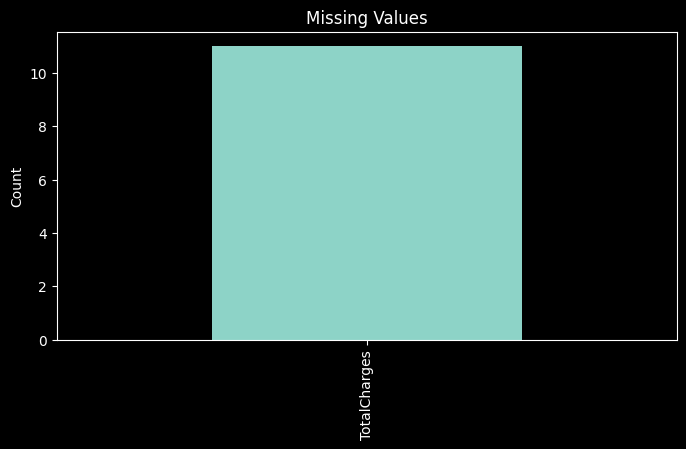

In [213]:
plt.figure(figsize=(8,4))
missing.plot(kind="bar")
plt.title("Missing Values")
plt.ylabel("Count")
plt.show()

# Duplicate Rows

In [214]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 22


# Target Distribution

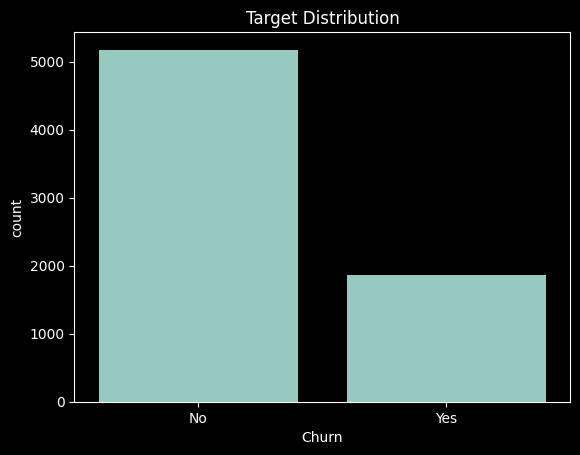

In [215]:
sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Target Distribution")

plt.show()

In [216]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

## Numerical Features Distribution

In [217]:
numerical = df.select_dtypes(include=np.number).columns

len(numerical)

4

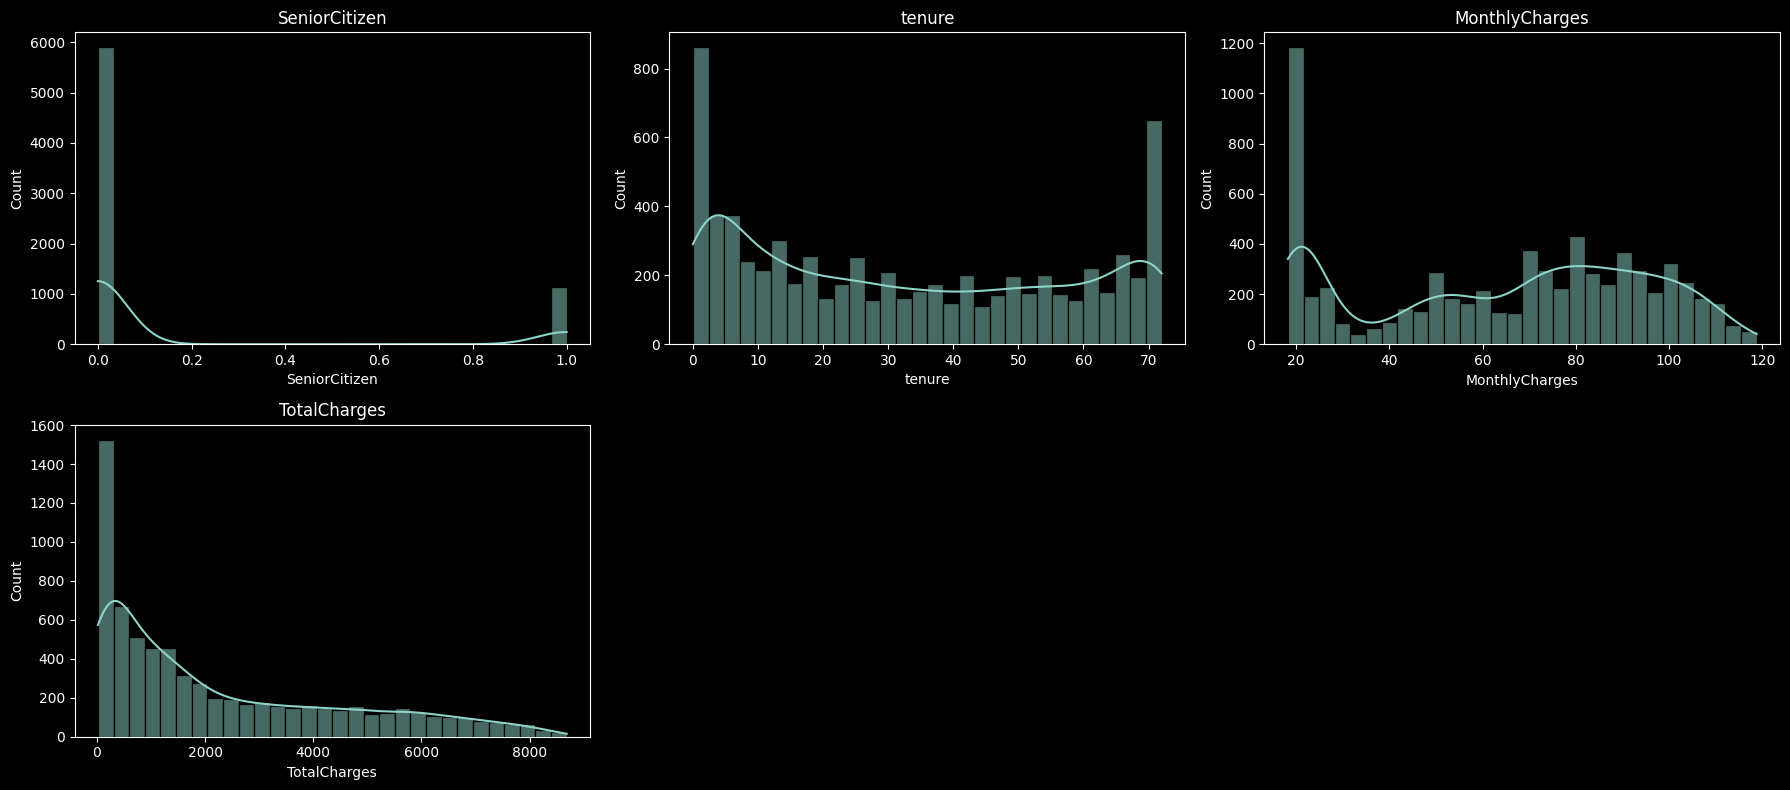

In [218]:
n_cols = 3
n_rows = math.ceil(len(numerical) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(numerical):

    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True,
        edgecolor="black",
        ax=axes[i]
    )

    axes[i].set_title(col)

for j in range(len(numerical), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

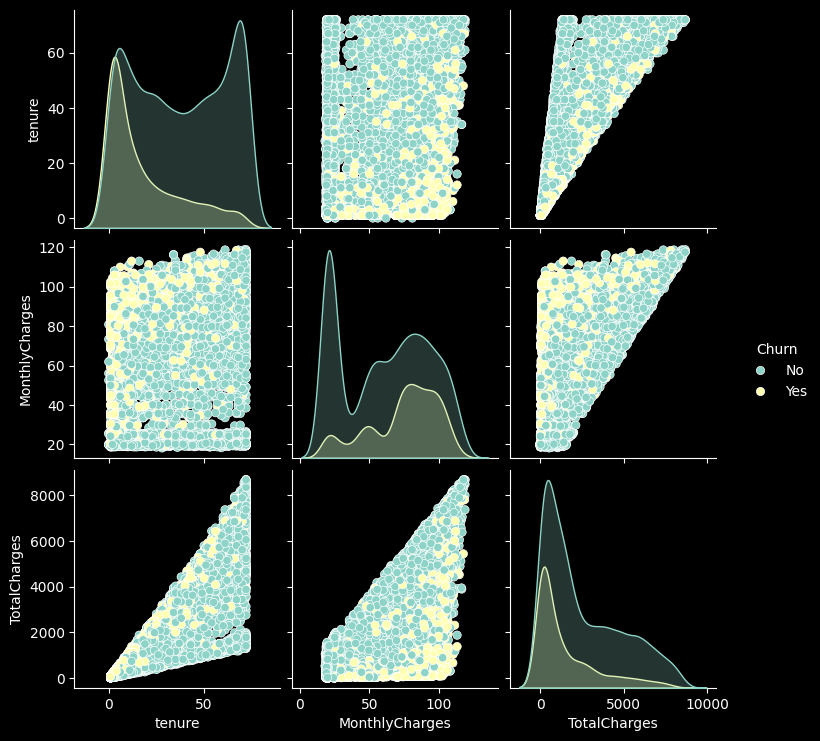

In [219]:
sns.pairplot(
    df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]],
    hue="Churn",
    diag_kind="kde"
)
plt.show()

# Categorical Features

In [220]:
categorical = df.select_dtypes(exclude=np.number).columns

len(categorical)

16

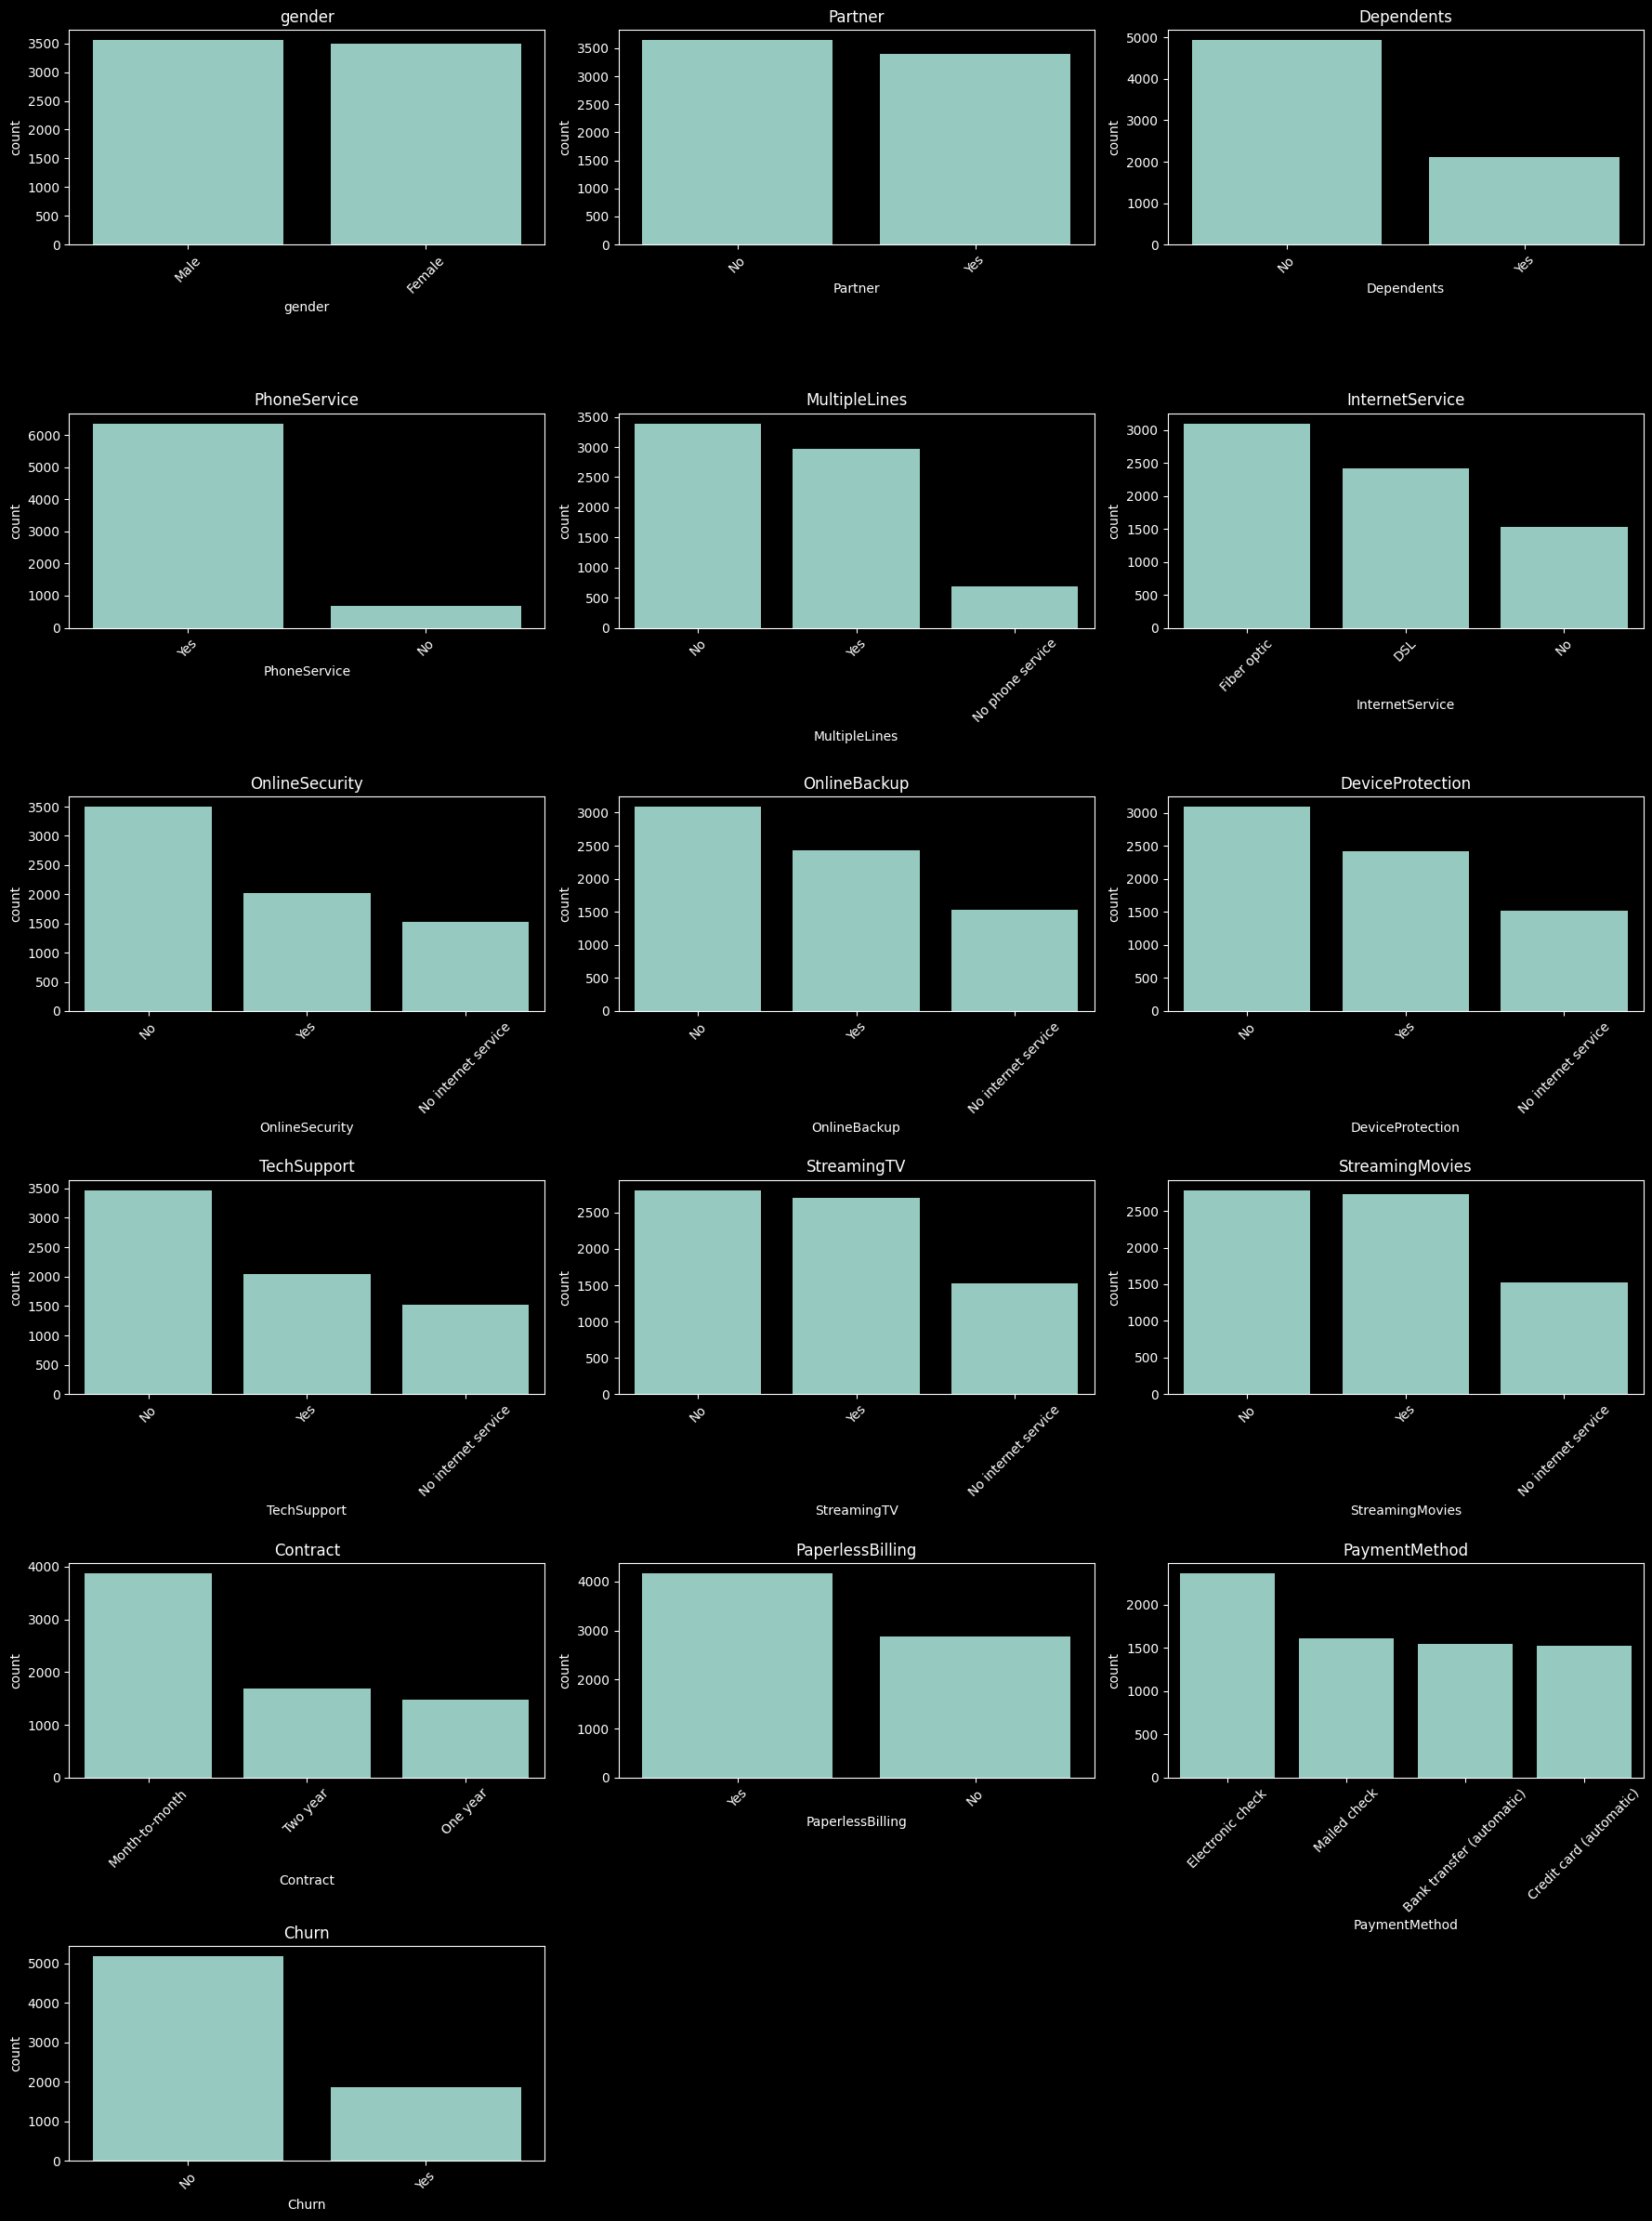

In [221]:
n_cols = 3
n_rows = math.ceil(len(categorical) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()
for i, col in enumerate(categorical):

    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index[:10],
        ax=axes[i]
    )
    axes[i].tick_params(
    axis="x",
    rotation=45
)
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(len(categorical), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Box plots for outlier detection

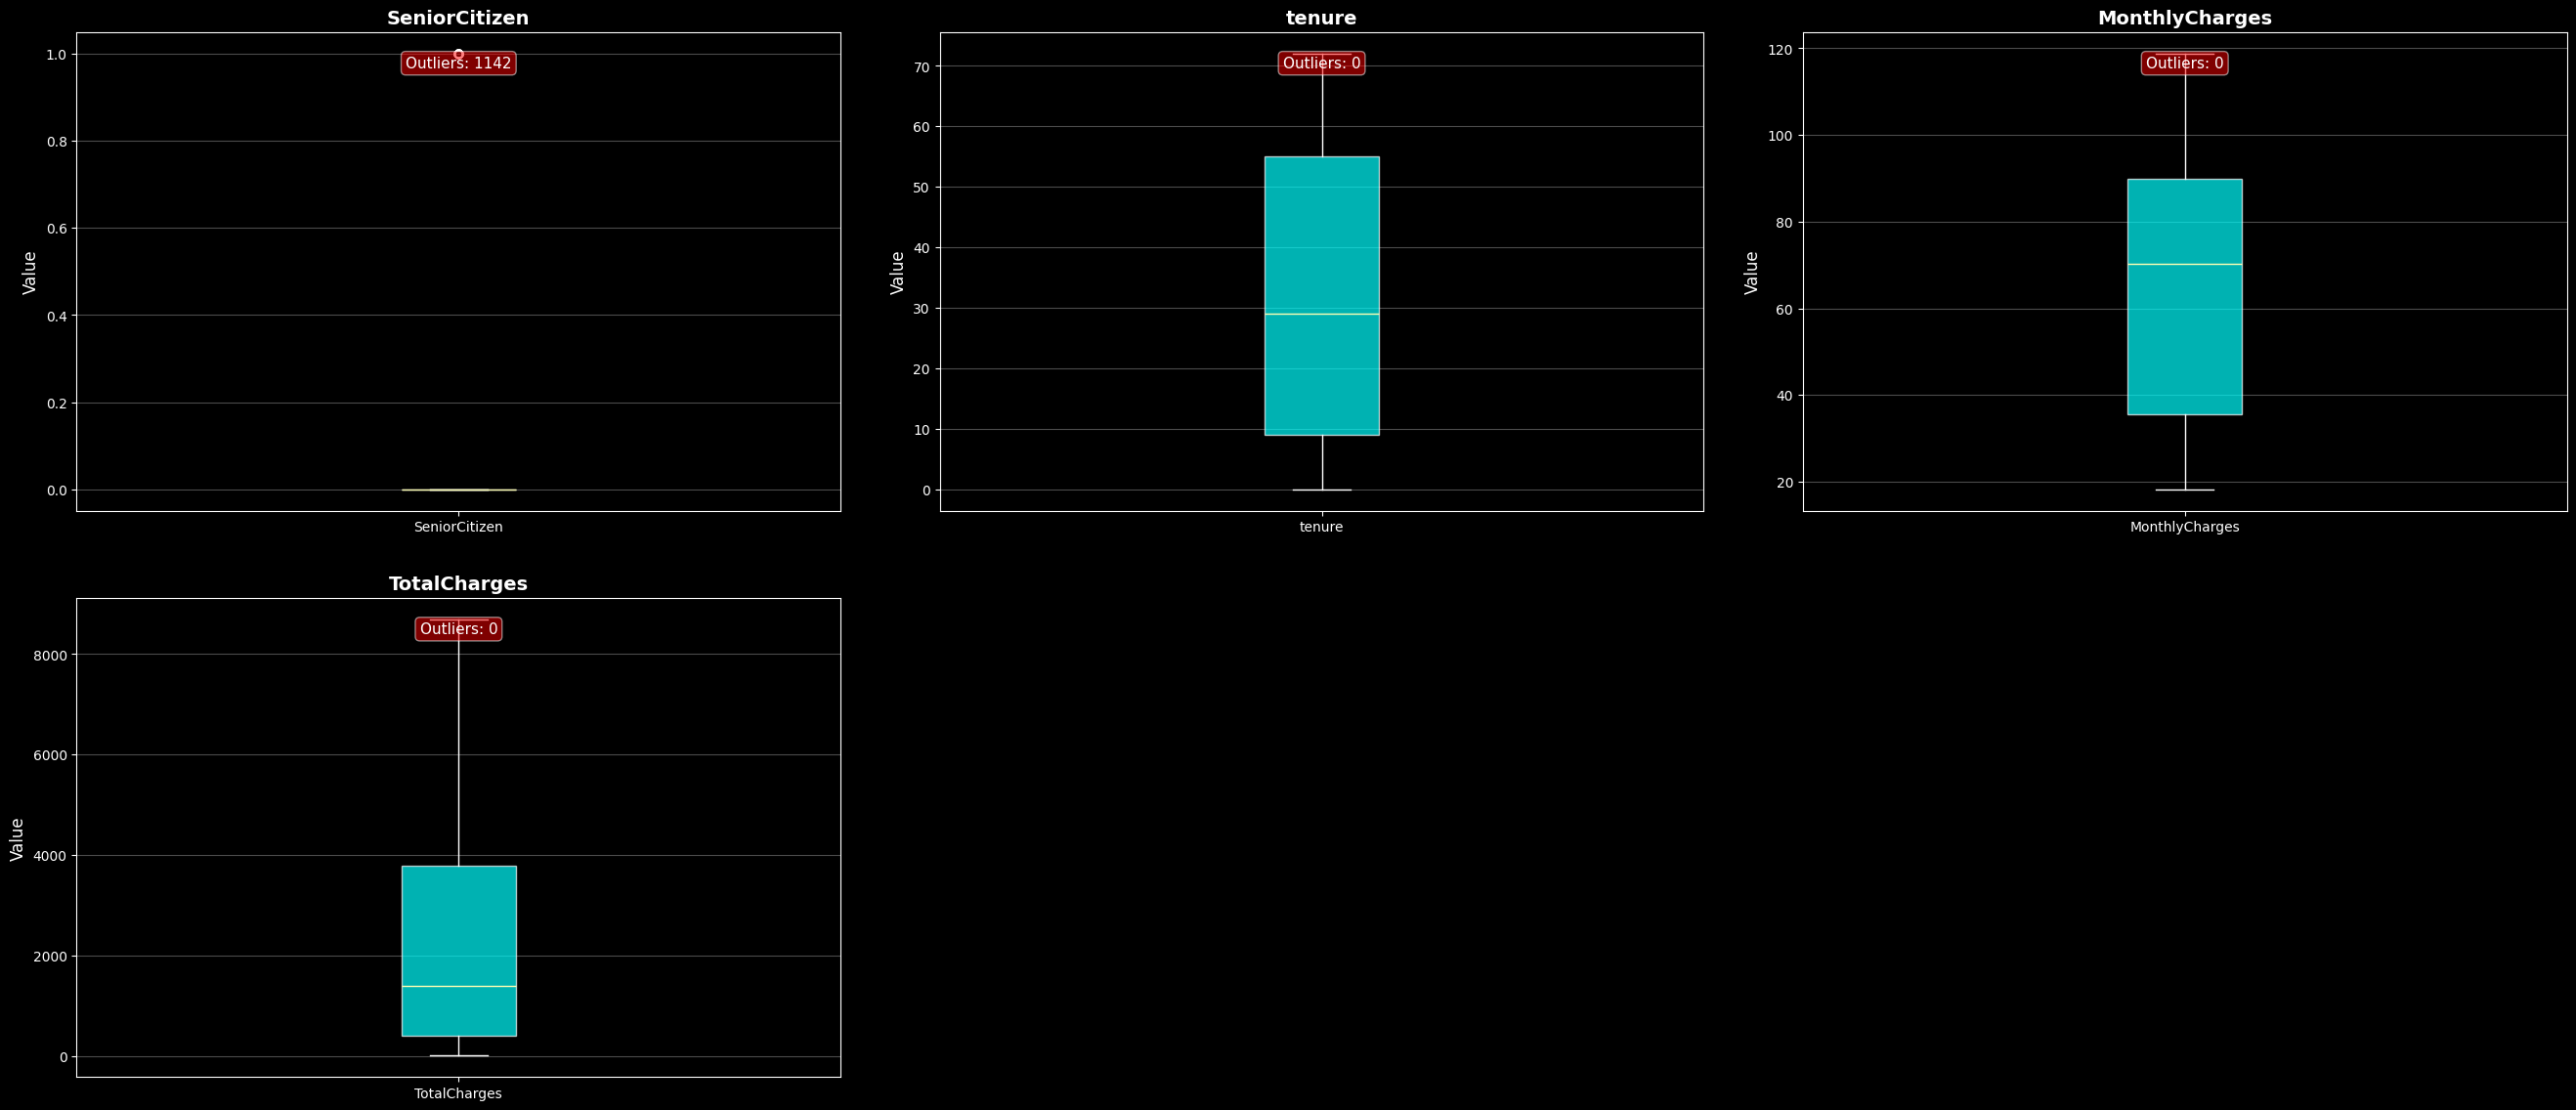

In [222]:
n_cols = 3
n_rows = math.ceil(len(numerical) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(9 * n_cols, 6 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numerical):
    bp = axes[i].boxplot([df[col].dropna()], tick_labels=[col], patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('cyan')
        patch.set_alpha(0.7)
    axes[i].set_ylabel('Value', fontsize=12)
    axes[i].set_title(f'{col}', fontsize=14, fontweight='bold')
    axes[i].grid(alpha=0.3, axis='y')

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    axes[i].text(0.5, 0.95, f'Outliers: {outliers}',
                 transform=axes[i].transAxes, ha='center', va='top',
                 bbox=dict(boxstyle='round', facecolor='red', alpha=0.5), fontsize=11)

for j in range(len(numerical), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=3.0)
plt.show()

# Correlation Heatmap

In [223]:
df_corr = df.copy()

df_corr["Churn"] = df_corr["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [224]:
from sklearn.preprocessing import LabelEncoder

df_corr_full = df_corr.copy()
cat_cols_to_encode = df_corr_full.select_dtypes(exclude=np.number).columns

le = LabelEncoder()
for col in cat_cols_to_encode:
    df_corr_full[col] = le.fit_transform(df_corr_full[col].astype(str))

corr_matrix = df_corr_full.corr()

print("Correlation with Target (Churn) - all features:")
print(corr_matrix['Churn'].sort_values(ascending=False))

Correlation with Target (Churn) - all features:
Churn               1.000000
MonthlyCharges      0.193356
PaperlessBilling    0.191825
SeniorCitizen       0.150889
PaymentMethod       0.107062
MultipleLines       0.038037
PhoneService        0.011942
gender             -0.008612
StreamingTV        -0.036581
StreamingMovies    -0.038492
InternetService    -0.047291
Partner            -0.150448
Dependents         -0.164221
DeviceProtection   -0.178134
OnlineBackup       -0.195525
TotalCharges       -0.199484
TechSupport        -0.282492
OnlineSecurity     -0.289309
tenure             -0.352229
Contract           -0.396713
Name: Churn, dtype: float64


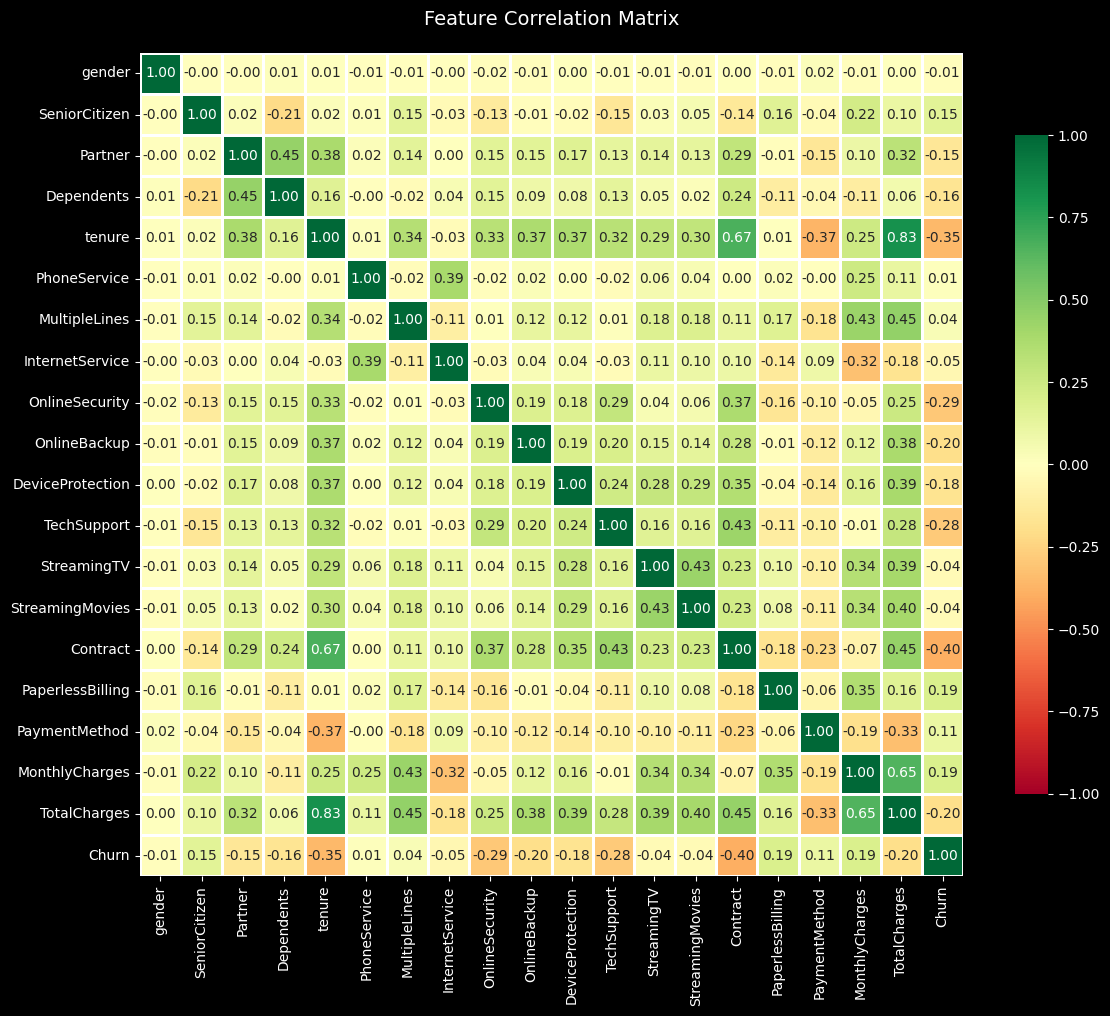

In [225]:
# Correlation heatmap .. note how the color reflects the value (use the colorbar on the right as the reference)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

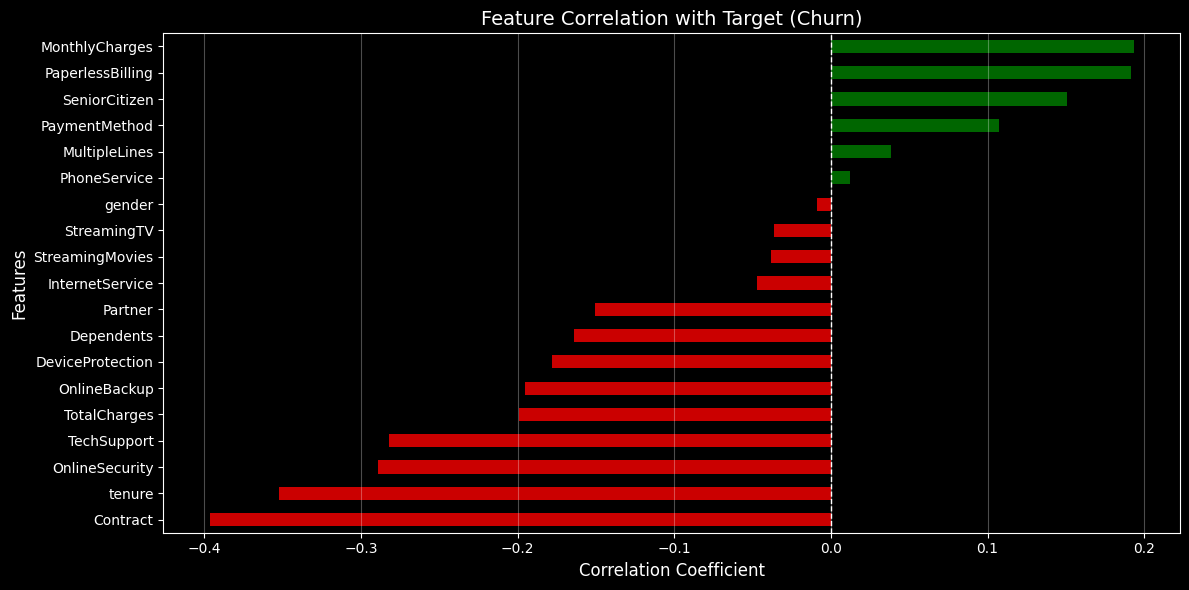

In [226]:
# Target correlation bar plot, see how we can use this plot to visualise correlation values
fig, ax = plt.subplots(figsize=(12, 6))
target_corr = corr_matrix['Churn'].drop('Churn').sort_values()
colors = ['red' if x < 0 else 'green' for x in target_corr]  # to change that to specific color based on direction of correlation
target_corr.plot(kind='barh', color=colors, ax=ax, alpha=0.8)
ax.set_xlabel('Correlation Coefficient', fontsize=12)
ax.set_ylabel('Features', fontsize=12)
ax.set_title('Feature Correlation with Target (Churn)', fontsize=14)
ax.axvline(0, color='white', linestyle='--', linewidth=1)
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Churn Rate by Category

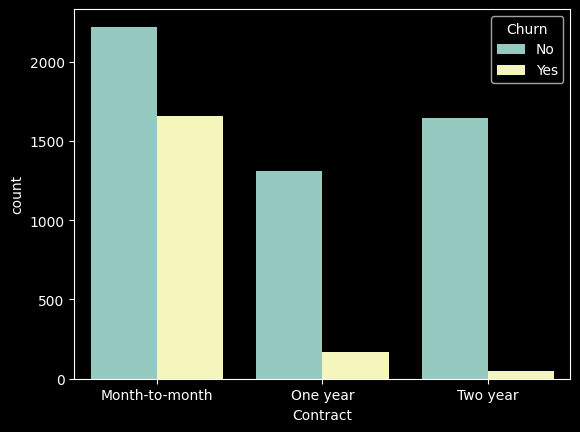

In [227]:
sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.show()

([0, 1, 2, 3],
 [Text(0, 0, 'Electronic check'),
  Text(1, 0, 'Mailed check'),
  Text(2, 0, 'Bank transfer (automatic)'),
  Text(3, 0, 'Credit card (automatic)')])

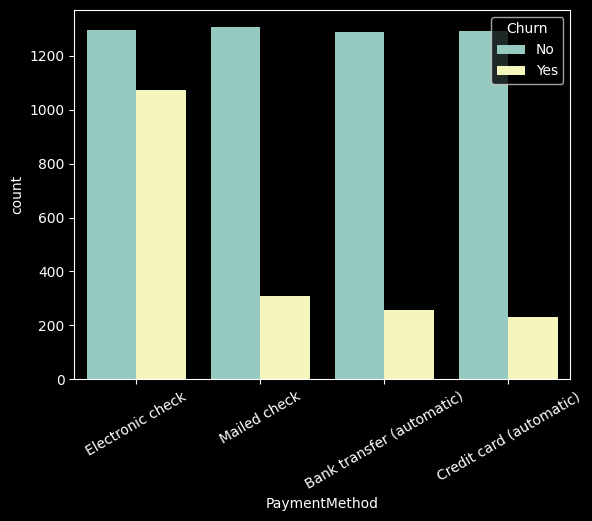

In [228]:
sns.countplot(data=df, x="PaymentMethod", hue="Churn")
plt.xticks(rotation=30)

## Key Findings

1. Customers with **month-to-month contracts** exhibit the highest churn rate compared to customers with one-year and two-year contracts.

2. Customers with **higher monthly charges** are more likely to churn than those with lower monthly charges.

3. Customers with **longer tenure** tend to remain with the company, indicating a strong negative relationship between tenure and churn.

4. Customers who use **Electronic Check** as their payment method show a higher churn rate than customers using other payment methods.

5. **TotalCharges** is negatively correlated with churn, suggesting that long-term, higher-spending customers are less likely to leave the company.